In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle
import time
import datetime as datetime
import matplotlib.pyplot as plt

In [3]:
class DEHNNLayer(nn.Module):
    def __init__(self, node_in_features, edge_in_features, vn_features, hidden_features):
        super(DEHNNLayer, self).__init__()
        self.node_mlp1 = nn.Sequential(nn.Linear(edge_in_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, edge_in_features))
        
        self.edge_mlp2 = nn.Sequential(nn.Linear(node_in_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, node_in_features))
        
        self.edge_mlp3 = nn.Sequential(nn.Linear(2 * node_in_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, 2 * node_in_features))

        self.node_to_virtual_mlp = nn.Sequential(nn.Linear(node_in_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, vn_features))
        
        self.virtual_to_higher_virtual_mlp = nn.Sequential(nn.Linear(vn_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, vn_features))
        
        self.higher_virtual_to_virtual_mlp = nn.Sequential(nn.Linear(vn_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, vn_features))
        
        self.virtual_to_node_mlp = nn.Sequential(nn.Linear(vn_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, edge_in_features))


    def forward(self, node_features, edge_features, vn_features, super_vn_features, hypergraph):

        # Node Update
        transformed_edge_features = self.node_mlp1(edge_features)
        updated_node_features = torch.matmul(hypergraph.incidence_matrix, transformed_edge_features)

        # Edge Update
        transformed_node_features = self.edge_mlp2(node_features)
        driver_features = torch.matmul(hypergraph.driver_matrix, transformed_node_features)
        sink_features = torch.matmul(hypergraph.sink_matrix, transformed_node_features)
        updated_edge_features = torch.cat([driver_features, sink_features], dim=1)
        updated_edge_features = self.edge_mlp3(updated_edge_features)
        
        # First Level VN Update
        node_to_virtual_features = self.node_to_virtual_mlp(node_features)
        updated_vn_features = torch.matmul(hypergraph.vn_matrix, node_to_virtual_features)
        updated_vn_features += self.higher_virtual_to_virtual_mlp(super_vn_features)

        # Top Level VN Update
        virtual_to_higher_virtual_features = self.virtual_to_higher_virtual_mlp(vn_features)
        updated_super_vn_features = torch.sum(virtual_to_higher_virtual_features, dim=0)

        # VN to node update
        virtual_to_node_features = self.virtual_to_node_mlp(vn_features)
        propagated_features = torch.matmul(hypergraph.vn_matrix.T, virtual_to_node_features)
        updated_node_features += propagated_features

        return updated_node_features, updated_edge_features, updated_vn_features, updated_super_vn_features


class DEHNN(nn.Module):
    def __init__(self, num_layers, node_in_features, edge_in_features, hidden_features=16):
        super(DEHNN, self).__init__()
        self.num_layers = num_layers
        self.layers = nn.ModuleList()
        
        # Create multiple layers for DEHNN
        vn_in_features = node_in_features
        for i in range(num_layers):
            self.layers.append(DEHNNLayer(node_in_features, edge_in_features, vn_in_features, hidden_features))
            node_in_features, edge_in_features = edge_in_features, node_in_features
            edge_in_features *= 2
        
        self.output_layer = nn.Sequential(nn.Linear(node_in_features, hidden_features),
                                       nn.ReLU(),
                                       nn.Linear(hidden_features, 1))

    def forward(self, node_features, edge_features, vn_features, super_vn_features, hypergraph):
        # Pass through each layer
        for layer in self.layers:
            node_features, edge_features, vn_features, super_vn_features = layer(node_features, edge_features, vn_features, super_vn_features, hypergraph)
        
        # Output prediction for nodes
        output = self.output_layer(node_features)
        return output

In [4]:
class Hypergraph:
    def __init__(self, incidence_matrix, driver_matrix, sink_matrix, vn_matrix):
        self.incidence_matrix = incidence_matrix
        self.driver_matrix = driver_matrix
        self.sink_matrix = sink_matrix
        self.vn_matrix = vn_matrix

In [73]:
def open_chip(i):
    path = f'../data/superblue/superblue_{i}/'

    with open(path + f'bipartite.pkl', 'rb') as f:
        bipartite = pickle.load(f)

    with open(path + f'degree.pkl', 'rb') as f:
        degree = pickle.load(f)

    with open(path + f'eigen.10.pkl', 'rb') as f:
        eigen = pickle.load(f)

    # with open(path + f'global_information.pkl', 'rb') as f:
    #     global_info = pickle.load(f)

    with open(path + f'metis_part_dict.pkl', 'rb') as f:
        metis = pickle.load(f)

    # with open(path + f'net_demand_capacity.pkl', 'rb') as f:
    #     net_demand_capacity = pickle.load(f)

    with open(path + f'net_features.pkl', 'rb') as f:
        net_feats = pickle.load(f)

    with open(path + f'net_hpwl.pkl', 'rb') as f:
        hpwl = pickle.load(f)

    # with open(path + f'nn_conn.pkl', 'rb') as f:
    #     nn_conn = pickle.load(f)

    with open(path + f'node_features.pkl', 'rb') as f:
        node_feats = pickle.load(f)

    with open(path + f'node_neighbor_features.pkl', 'rb') as f:
        node_neighbor_feats = pickle.load(f)

    # with open(path + f'pl_fix_part_dict.pkl', 'rb') as f:
    #     pl = pickle.load(f)

    # with open(path + f'star.pkl', 'rb') as f:
    #     star = pickle.load(f)

    with open(path + f'targets.pkl', 'rb') as f:
        targets = pickle.load(f)

    # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device = 'cpu'

    incidence_matrix = torch.sparse_coo_tensor(torch.tensor(np.array([bipartite['instance_idx'], bipartite['net_idx']])), torch.ones(bipartite['edge_dir'].shape), dtype=torch.float).to(device)

    driver_idx = bipartite['edge_dir'] == 1
    driver_row = bipartite['instance_idx'][driver_idx]
    driver_col = bipartite['net_idx'][driver_idx]
    driver_dir = bipartite['edge_dir'][driver_idx]
    driver_matrix = torch.sparse_coo_tensor(torch.tensor(np.array([driver_col, driver_row])), torch.ones(driver_dir.shape), dtype=torch.float).to(device)

    sink_idx = bipartite['edge_dir'] == 0
    sink_row = bipartite['instance_idx'][sink_idx]
    sink_col = bipartite['net_idx'][sink_idx]
    sink_dir = bipartite['edge_dir'][sink_idx]
    sink_matrix = torch.sparse_coo_tensor(torch.tensor(np.array([sink_col, sink_row])), torch.ones(sink_dir.shape), dtype=torch.float).to(device)

    num_nodes = node_feats['num_instances']
    node_features = node_feats['instance_features'][:, 2:]
    node_features = torch.tensor(node_features, dtype=torch.float)
    cell_degrees = torch.tensor(degree['cell_degrees'])
    net_degrees = torch.tensor(degree['net_degrees'])
    node_features = torch.cat([node_features, cell_degrees.unsqueeze(dim = 1)], dim = 1)
    edge_features = net_degrees.unsqueeze(dim = 1)

    evects_node = torch.tensor(eigen['evects'][:num_nodes])
    evects_net = torch.tensor(eigen['evects'][num_nodes:])
    node_features = torch.cat([node_features, evects_node], dim=1)
    edge_features = torch.cat([edge_features, evects_net], dim=1)

    # pd = torch.Tensor(node_neighbor_feats['pd'])
    neighbor_list = torch.Tensor(node_neighbor_feats['neighbor'])
    node_features = torch.cat([node_features, neighbor_list], dim = 1)

    node_features = node_features.to(device)
    edge_features = edge_features.to(device)

    num_nodes, num_node_features = node_features.shape
    num_edges, num_edge_features = edge_features.shape
    demand = targets['demand'].reshape(num_nodes,1)
    demand = torch.tensor(demand, dtype=torch.float).to(device)
    demand = (demand - torch.mean(demand)) / torch.std(demand)
    wire = hpwl['hpwl'].reshape(num_edges,1)
    wire = torch.tensor(wire, dtype=torch.float).to(device)

    vn_row = []
    vn_col = []

    for k, v in metis.items():
        if k < num_nodes:
            vn_row.append(v)
            vn_col.append(k)

    vn_matrix = torch.sparse_coo_tensor(torch.tensor(np.array([vn_row, vn_col])), torch.ones(len(vn_row)), dtype=torch.float).to(device)

    num_vn = vn_matrix.shape[0]
    num_vn_features = num_node_features
    vn_features = torch.zeros((num_vn, num_vn_features), dtype=torch.float).to(device)
    super_vn_features = torch.zeros(num_vn_features, dtype=torch.float).to(device)

    hypergraph = Hypergraph(incidence_matrix, driver_matrix, sink_matrix, vn_matrix)

    return node_features, edge_features, vn_features, super_vn_features, hypergraph, demand

In [75]:
node_features, edge_features, vn_features, super_vn_features, hypergraph, demand = open_chip(19)

In [76]:
demand

tensor([[-0.5425],
        [-0.7202],
        [-0.8980],
        ...,
        [-1.3423],
        [ 0.2573],
        [-0.1871]])

In [44]:
path = f'../data/superblue/superblue_{19}/'
with open(path + f'node_features.pkl', 'rb') as f:
    node_feats = pickle.load(f)

with open(path + f'targets.pkl', 'rb') as f:
    targets = pickle.load(f)

In [50]:
targets

{'demand': array([ 8.33333333,  6.66666667,  5.        , ...,  0.83333333,
        15.83333333, 11.66666667]),
 'capacity': array([23.33333333, 24.16666667, 23.33333333, ...,  2.5       ,
        21.66666667, 21.66666667]),
 'classify': tensor([[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]])}

In [77]:
model = torch.load('demand_superblue.pt')

C:\Users\rebal\AppData\Local\Temp\ipykernel_17172\4258136797.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('demand_superblue.pt')


In [78]:
output = model(node_features, edge_features, vn_features, super_vn_features, hypergraph)

In [79]:
output

tensor([[-0.4433],
        [-0.3270],
        [-0.5158],
        ...,
        [ 0.1712],
        [ 0.0575],
        [ 0.0610]], grad_fn=<AddmmBackward0>)

In [80]:
prediction = output.detach().cpu().numpy()
actual = demand.detach().cpu().numpy()

mae = np.mean(np.abs(prediction - actual))
print(f'MAE: {mae}')

rmse = np.sqrt(np.mean((prediction - actual) ** 2))
print(f'RMSE: {rmse}')

MAE: 1.143790364265442
RMSE: 1.5925482511520386


In [81]:
df = pd.DataFrame({'pred': prediction.flatten(), 'actual': actual.flatten()})

In [82]:
df['diff'] = np.abs(df['pred'] - df['actual'])

In [83]:
df.sort_values('diff', ascending=False).head(20)

,pred,actual,diff
440337,222.183777,0.968155,221.215622
440362,153.524887,-1.431137,154.956024
440365,144.930481,-1.342275,146.272751
440339,59.465168,-1.342275,60.807442
440332,28.030790,-1.342275,29.373066
440343,-22.460499,-1.075687,21.384811
440356,-19.334888,-0.542511,18.792377
440381,-19.352818,-0.631373,18.721445
440372,-14.307655,-0.453648,13.854008
440351,-14.223763,-0.809099,13.414664


In [84]:
baseline = pd.read_csv('baseline_1_1000.csv')
baseline['Training'] = np.sqrt(baseline['Train_Loss'])
baseline['Validation'] = np.sqrt(baseline['Valid_Loss'])
baseline

,Epoch,Train_Loss,Valid_Loss,Time,Training,Validation
0,1,3.129057e+07,6.872370e+06,19.50,5593.797824,2621.520551
1,2,3.191757e+07,8.878227e+04,39.34,5649.563266,297.963531
2,3,5.627420e+05,3.643714e+05,58.76,750.161289,603.631847
3,4,1.812197e+06,2.677641e+05,79.39,1346.178782,517.459268
4,5,1.474735e+05,3.500209e+04,100.53,384.022809,187.088455
...,...,...,...,...,...,...
995,996,1.032160e+00,5.095058e+00,21116.04,1.015953,2.257224
996,997,1.032083e+00,5.094963e+00,21137.91,1.015915,2.257202
997,998,1.032007e+00,5.094871e+00,21159.60,1.015877,2.257182
998,999,1.031930e+00,5.094795e+00,21181.68,1.015840,2.257165


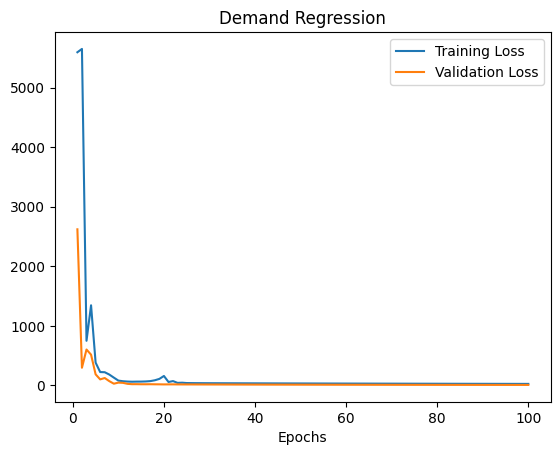

In [86]:
results = baseline.iloc[0:100]
plt.title('Demand Regression')
plt.plot(results['Epoch'], results['Training'], label='Training Loss')
plt.plot(results['Epoch'], results['Validation'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.show()